In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list

# Predicted serotype data from ML

In [7]:
sero_pred = pd.read_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/serotypes_predicted.csv')
sero_pred = sero_pred[['Sample_ID','all_serotypes']]
print('Number of rows and columns',sero_pred.shape)
sero_pred = sero_pred.rename(columns = {'all_serotypes':'serogroup_serotype'})
sero_pred['serogroup_serotype'].value_counts()

Number of rows and columns (1866, 2)


serogroup_serotype
non_O1          906
O1_Ogawa        535
O1_Inaba        424
O1_Hikoshima      1
Name: count, dtype: int64

# Cluster data

In [14]:
clusters = pd.read_csv("/media/dell/My Passport/vc_files_v_final/2_population structure/pcoa_clusters.csv")
clusters = clusters.rename(columns = {'index':'Sample_ID'})
clusters.columns
cluster_col = clusters[['Sample_ID', 'Cluster']]

In [4]:
cluster_1_genomes = cluster_col[cluster_col['Cluster'] == 'Cluster A']
cluster_1_genomes.columns

Index(['Sample_ID', 'Cluster'], dtype='object')

In [5]:
cluster_1_sample_ids = cluster_1_genomes['Sample_ID'].tolist()

In [6]:
other_sample_ids = cluster_col[cluster_col['Cluster'] != 'Cluster A']['Sample_ID'].tolist()
#other_sample_ids

# chisq test tables

In [7]:
def chi_square_test(df, metadata_cols=["Sample_ID", "serogroup_serotype"], alpha=0.05):
    gene_cols = [col for col in df.columns if col not in metadata_cols]  # only gene columns
    print(f"Total genes/mge: {len(gene_cols)}")
    
    results = []
    for gene in gene_cols:
        cross = pd.crosstab(df["serogroup_serotype"], df[gene])  # contingency table (gene and serotypes)
        if cross.shape[1] <= 1:   # if there is no variation, the genes are skipped
            continue

        chi2, p, _, _ = chi2_contingency(cross) # chi2 test
        percent = df.groupby("serogroup_serotype")[gene].mean() * 100  # percentage wise presence
        row = {"Gene": gene, "Chi2": chi2, "p_value": p}
        for serotype in percent.index:
            row[f"{serotype}_%"] = round(percent[serotype], 2)  # adding serotype columns (percentage wise distribution)
        
        results.append(row)   # gene chi2_value p_value %ofserotypes(4 columns)

    final_table = pd.DataFrame(results)
    final_table = final_table.sort_values("p_value")  # sorting by p_value
    print(f"Genes/mge tested after filtering: {len(final_table)}")
    
    final_table["p_adjusted"] = multipletests(final_table["p_value"], method="fdr_bh")[1]  # multiple testing corrections using Benjamini-Hochberg false discovery rate
    significant = final_table[final_table["p_adjusted"] < alpha]   # significant p_values
    print(f"\nSignificant genes/mge (raw p < {alpha}): {(final_table['p_value'] < alpha).sum()}")
    print(f"Significant genes/mge (adjusted p < {alpha}): {len(significant)}")
    print("\nTop 5 results:")
    print(final_table.head())
    
    if len(significant) > 0:
        print("\nSignificant genes/MGE:")
        print(significant.head())
    else:
        print("\nNo significant genes/MGE found after correction.")
    
    return final_table, significant

## AMR genes

In [8]:
amr_df = pd.read_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/amr_presence.csv')
amr_df = amr_df.drop(columns=['Unnamed: 0'])
amr_df
amr_df = amr_df.merge(sero_pred, on = 'Sample_ID')

In [9]:
final_table, significant_genes_adj = chi_square_test(amr_df)

Total genes/mge: 120
Genes/mge tested after filtering: 118

Significant genes/mge (raw p < 0.05): 41
Significant genes/mge (adjusted p < 0.05): 36

Top 5 results:
        Gene        Chi2        p_value  O1_Hikoshima_%  O1_Inaba_%  \
9      catB9  850.220856  5.547569e-184           100.0       79.95   
5      dfrA1  782.126105  3.255418e-169             0.0       54.01   
7       varG  706.283038  9.112344e-153           100.0       97.88   
6  gyrA_S83I  439.513588   6.098851e-95             0.0       51.18   
2  aph(6)-Id  422.952976   2.360682e-91             0.0       46.46   

   O1_Ogawa_%  non_O1_%     p_adjusted  
9       90.47     18.87  6.546132e-182  
5       67.48      1.66  1.920697e-167  
7       98.32     42.27  3.584188e-151  
6       63.74     12.47   1.799161e-93  
2       55.51      8.17   4.642674e-90  

Significant genes/MGE:
        Gene        Chi2        p_value  O1_Hikoshima_%  O1_Inaba_%  \
9      catB9  850.220856  5.547569e-184           100.0       79.95  

In [42]:
final_table.to_csv('/media/dell/My Passport/vc_files_v_final/tables/1_sup_amr_chisq.csv')

## Virulence genes

In [9]:
vir_df = pd.read_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/vir_presence.csv')
vir_df = vir_df.drop(columns=['Unnamed: 0'])
vir_df
vir_df = vir_df.merge(sero_pred, on = 'Sample_ID')

In [11]:
final_table, significant_genes_adj = chi_square_test(vir_df)

Total genes/mge: 50
Genes/mge tested after filtering: 42

Significant genes/mge (raw p < 0.05): 35
Significant genes/mge (adjusted p < 0.05): 35

Top 5 results:
    Gene         Chi2        p_value  O1_Hikoshima_%  O1_Inaba_%  O1_Ogawa_%  \
32  tcpA  1289.206457  3.234541e-279             0.0       83.02       92.15   
23  tcpF  1288.806255  3.950464e-279             0.0       85.61       91.40   
31  tcpB  1221.531612  1.561451e-264             0.0       87.74       93.64   
17  acfD  1218.955725  5.654800e-264             0.0       87.03       93.46   
33  tcpH  1218.566813  6.867511e-264             0.0       87.50       93.64   

    non_O1_%     p_adjusted  
32      5.30  8.295975e-278  
23      5.85  8.295975e-278  
31     10.26  2.186031e-263  
17      9.93  5.768709e-263  
33     10.26  5.768709e-263  

Significant genes/MGE:
    Gene         Chi2        p_value  O1_Hikoshima_%  O1_Inaba_%  O1_Ogawa_%  \
32  tcpA  1289.206457  3.234541e-279             0.0       83.02       92.

In [45]:
final_table.to_csv('/media/dell/My Passport/vc_files_v_final/tables/1_sup_vir_chisq.csv')

## Integrons

In [10]:
int_df = pd.read_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/int_presence.csv')
int_df = int_df.drop(columns=['Unnamed: 0'])
int_df = int_df.rename(columns = {'index':'Sample_ID'})
#int_df
int_df = int_df.merge(sero_pred, on = 'Sample_ID')

In [13]:
final_table, significant_genes_adj = chi_square_test(int_df)

Total genes/mge: 44
Genes/mge tested after filtering: 44

Significant genes/mge (raw p < 0.05): 13
Significant genes/mge (adjusted p < 0.05): 9

Top 5 results:
               Gene        Chi2        p_value  O1_Hikoshima_%  O1_Inaba_%  \
28   In444|GQ891757  663.983411  1.353647e-143             0.0       10.38   
22   In251|HQ386834  400.324405   1.883158e-86             0.0       16.98   
26   In363|DQ402098  357.927835   2.864206e-77             0.0       36.79   
40   In805|KU886277   37.338099   3.902542e-08           100.0       95.52   
7   In1291|KU145265   33.503957   2.521290e-07             0.0       24.06   

    O1_Ogawa_%  non_O1_%     p_adjusted  
28       93.27     57.17  5.956049e-142  
22       39.63      0.33   4.142948e-85  
26       27.66      0.00   4.200835e-76  
40       98.88     99.78   4.292796e-07  
7        35.51     40.18   2.218735e-06  

Significant genes/MGE:
               Gene        Chi2        p_value  O1_Hikoshima_%  O1_Inaba_%  \
28   In444|GQ8917

In [48]:
final_table.to_csv('/media/dell/My Passport/vc_files_v_final/tables/1_sup_int_chisq.csv')

## Transposons

In [11]:
transposon_df = pd.read_csv('/media/dell/My Passport/vc_files_v_final/3_supervised_learning/2_serotype/transposon_presence.csv')
transposon_df = transposon_df.drop(columns=['Unnamed: 0'])
transposon_df = transposon_df.rename(columns = {'index':'Sample_ID'})
#transposon_df
transposon_df = transposon_df.merge(sero_pred, on = 'Sample_ID')

In [15]:
final_table, significant_genes_adj = chi_square_test(transposon_df)

Total genes/mge: 23
Genes/mge tested after filtering: 23

Significant genes/mge (raw p < 0.05): 3
Significant genes/mge (adjusted p < 0.05): 1

Top 5 results:
               Gene       Chi2   p_value  O1_Hikoshima_%  O1_Inaba_%  \
8   Tn5057|AJ302768  27.938958  0.000004             0.0        0.00   
10  Tn5074|AF461012   9.582642  0.022468             0.0        0.00   
11   Tn512|EU306744   9.582642  0.022468             0.0        0.00   
9   Tn5073|AF461013   4.247516  0.235948             0.0        0.00   
4   Tn4352|HQ840942   4.236842  0.236999             0.0        0.24   

    O1_Ogawa_%  non_O1_%  p_adjusted  
8          0.0      2.87    0.000086  
10         0.0      0.99    0.172257  
11         0.0      0.99    0.172257  
9          0.0      0.44    0.946406  
4          0.0      0.66    0.946406  

Significant genes/MGE:
              Gene       Chi2   p_value  O1_Hikoshima_%  O1_Inaba_%  \
8  Tn5057|AJ302768  27.938958  0.000004             0.0         0.0   

   O1_O

In [51]:
final_table.to_csv('/media/dell/My Passport/vc_files_v_final/tables/1_sup_transposon_chisq.csv')

# Combined heatmaps

## Loading the chisq test tables - transposons have not been included since they did not show significant variation in the serotypes

In [12]:
amr_results = pd.read_csv("/media/dell/My Passport/vc_files_v_final/tables/1_sup_amr_chisq.csv").drop(columns=["Unnamed: 0"])
vir_results = pd.read_csv("/media/dell/My Passport/vc_files_v_final/tables/1_sup_vir_chisq.csv").drop(columns=["Unnamed: 0"])
int_results = pd.read_csv("/media/dell/My Passport/vc_files_v_final/tables/1_sup_int_chisq.csv").drop(columns=["Unnamed: 0"])

## significant gene filtering

In [15]:
sig_amr = amr_results.loc[amr_results["p_adjusted"] < 0.05, "Gene"].tolist()
sig_vir = vir_results.loc[vir_results["p_adjusted"] < 0.05, "Gene"].tolist()
sig_int = int_results.loc[int_results["p_adjusted"] < 0.05, "Gene"].tolist()

# merging with the PCoA cluster details
merged_amr = amr_df.merge(cluster_col, on="Sample_ID", how="left")
merged_vir = vir_df.merge(cluster_col, on="Sample_ID", how="left")
merged_int = int_df.merge(cluster_col, on="Sample_ID", how="left")

## sorting based on clusters

In [16]:
def prepare_panel_data(df, genes):
    df = df.sort_values("Cluster")
    heatmap_data = df[genes].T
    return heatmap_data

amr_heat = prepare_panel_data(merged_amr, sig_amr)
vir_heat = prepare_panel_data(merged_vir, sig_vir)
int_heat = prepare_panel_data(merged_int, sig_int)

In [17]:
# clustering was done for the ease of interpretability and visulalisation

def get_clustered_heatmap_data(merged,significant_genes_adj,cluster_col="Cluster",sample_col="Sample_ID"):
    sig_genes = significant_genes_adj  # list of significant genes
    merged_sorted = merged.sort_values(cluster_col)  # sorting genomes based on cluster categories
    gene_data_sorted = merged_sorted[sig_genes] # choosing significant gene/mge
    gene_data_sorted.index = merged_sorted[sample_col] # sample_ID as the row index
    heatmap_data = gene_data_sorted.transpose() # genes - rows and genomes - columns

    Z = linkage(heatmap_data.values,method="average",metric="euclidean") # gene clustering based on presence/absence 
    ordered_rows = leaves_list(Z) # gene order cluster wise
    heatmap_data = heatmap_data.iloc[ordered_rows] # rearranging based on clustering
    return heatmap_data


amr_heat = get_clustered_heatmap_data(merged_amr,sig_amr)
vir_heat= get_clustered_heatmap_data(merged_vir,sig_vir)
int_heat = get_clustered_heatmap_data(merged_int,sig_int)

In [18]:
## highlighting important gene patterns
# AMR
amr_top_blue = set(sig_amr[:9])
amr_top_red = set()

# Virulence
vir_top_blue = set(sig_vir[:23])
vir_top_red = set(sig_vir[23:25])

# Integron
int_top_blue = set(sig_int[:4])
int_top_red = set()

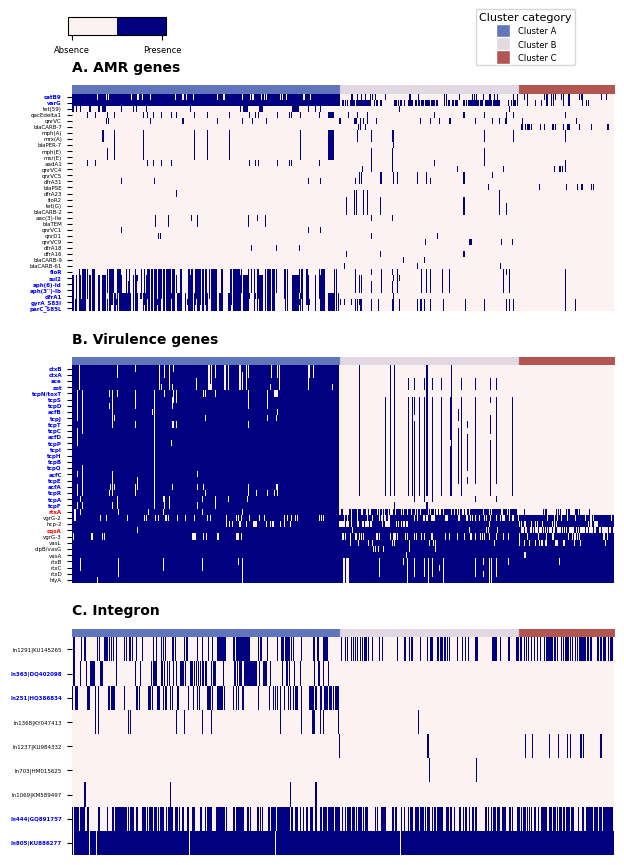

In [63]:
cluster_order = merged_amr.sort_values("Cluster")["Cluster"] # sorting clusters
cluster_ids = cluster_order.unique()  # 3 clusters

palette = sns.color_palette("twilight_shifted",len(cluster_ids))  # one color for each clusters

lut = dict(zip(cluster_ids, palette)) 
cluster_colors = np.array([lut[x] for x in cluster_order]).reshape(1, -1, 3) # color nd cluster mapping

cmap = ListedColormap(["#FCF2F2", "#000080"]) # presence absence colors

fig = plt.figure(figsize=(7,10))
outer = gridspec.GridSpec(3, 1,hspace=0.20)  # 3 panels with appropriate spacing

# AMR heatmap -panel A
innerA = gridspec.GridSpecFromSubplotSpec(2, 1,subplot_spec=outer[0], # first panel
                                          height_ratios=[0.04, 1], # cluster strip space: heatmap space
                                          hspace=0) # no gap between cluster strip and heatmap

axA_strip = fig.add_subplot(innerA[0])  # axis for cluster strip
axA = fig.add_subplot(innerA[1]) # axis for heatmap

axA_strip.imshow(np.array(list(cluster_colors)).reshape(1,-1,3),aspect="auto") # cluster color plots
axA_strip.set_xticks([])
axA_strip.set_yticks([]) # removing the axis labels from cluster strips

axA_strip.set_title("A. AMR genes",loc="left",fontsize=10,fontweight="bold",pad=10) # panel title

sns.heatmap(amr_heat,cmap=cmap,cbar=False,xticklabels=False,yticklabels=1,ax=axA) # heatmap for significant AMR genes

for lab in axA.get_yticklabels():
    gene = lab.get_text()  # gene names
    if gene in amr_top_blue:
        lab.set_color("blue")
        lab.set_fontweight("bold") # genes to highlight in blue
    elif gene in amr_top_red:
        lab.set_color("red")
        lab.set_fontweight("bold") # genes to highlight in red

# Virulence heatmap - panel B
innerB = gridspec.GridSpecFromSubplotSpec(2, 1,subplot_spec=outer[1],  # second panel
                                          height_ratios=[0.04, 1], # cluster strip space: heatmap space
                                          hspace=0) # no gap between cluster strip and heatmap

axB_strip = fig.add_subplot(innerB[0]) # axis for cluster strip
axB = fig.add_subplot(innerB[1]) # axis for heatmap

axB_strip.imshow(np.array(list(cluster_colors)).reshape(1,-1,3),aspect="auto") # cluster color plots
axB_strip.set_xticks([])
axB_strip.set_yticks([]) # removing the axis labels from cluster strips

axB_strip.set_title("B. Virulence genes",loc="left",fontsize=10,fontweight="bold",pad=10) # panel title
 
sns.heatmap(vir_heat,cmap=cmap,cbar=False,xticklabels=False,yticklabels=1,ax=axB)  # heatmap for significant virulence genes

for lab in axB.get_yticklabels():
    gene = lab.get_text() # gene names
    if gene in vir_top_blue:
        lab.set_color("blue")
        lab.set_fontweight("bold")  # genes to highlight in blue
    elif gene in vir_top_red:
        lab.set_color("red")
        lab.set_fontweight("bold") # genes to highlight in red

# integron heatmap - pane C
innerC = gridspec.GridSpecFromSubplotSpec(2, 1,subplot_spec=outer[2], # thirs panel
                                          height_ratios=[0.04, 1], # cluster strip space: heatmap space
                                          hspace=0) # no gap between cluster strip and heatmap

axC_strip = fig.add_subplot(innerC[0]) # axis for cluster strip
axC = fig.add_subplot(innerC[1]) # axis for heatmap

axC_strip.imshow(np.array(list(cluster_colors)).reshape(1,-1,3),aspect="auto") # cluster color plots
axC_strip.set_xticks([])
axC_strip.set_yticks([]) # removing the axis labels from cluster strips

axC_strip.set_title("C. Integron",loc="left",fontsize=10,fontweight="bold",pad=10) # panel title

hm = sns.heatmap(int_heat,cmap=cmap,cbar=False,xticklabels=False,yticklabels=1,ax=axC) # heatmap for significant virulence genes

for lab in axC.get_yticklabels():
    gene = lab.get_text() # gene names
    if gene in int_top_blue:
        lab.set_color("blue")
        lab.set_fontweight("bold") # genes to highlight in blue
    elif gene in int_top_red:
        lab.set_color("red")
        lab.set_fontweight("bold") # genes to highlight in red

# cluster legend
legend_elements = [Line2D([0], [0],marker='s',color='w',markerfacecolor=col,markersize=10,label=cluster)for cluster, col in lut.items()]
fig.legend(handles=legend_elements,title="Cluster category",bbox_to_anchor=(0.85, 0.96),loc="upper right",fontsize=6,title_fontsize=8,frameon=True)

#presence absence legend
#cax = fig.add_axes([0.08, 0.91, 0.015, 0.08])
cax = fig.add_axes([0.12, 0.93, 0.14, 0.018])
cb = fig.colorbar(hm.collections[0],cax=cax, orientation="horizontal")  # presence absence colorbar and axis

cb.set_ticks([0.04, 0.96])
cb.set_ticklabels(["Absence", "Presence"], fontsize=6)

for strip_ax in [axA_strip, axB_strip, axC_strip]:
    for spine in strip_ax.spines.values():
        spine.set_visible(False)  # removing border around the cluster strips

for ax in [axA, axB, axC]:
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", bottom=False)
    ax.tick_params(axis="y", labelsize=4)

plt.savefig("/media/dell/My Passport/vc_files_v_final/plots/final/pdf_files/3_combined_acc_mge_heatmap.pdf",bbox_inches="tight")
plt.savefig("/media/dell/My Passport/vc_files_v_final/plots/final/tif_files/3_combined_acc_mge_heatmap.tiff",dpi=300,bbox_inches="tight",pil_kwargs={"compression": "tiff_lzw"})
plt.show()

In [73]:
# verified consistent with the prevvious output
# as per the previous the cluster mapping was not saved previously and had to be repeated in the code.. That is fixed 